In [44]:
# pip install pytesseract


In [45]:
from PIL import Image
from io import BytesIO
import cv2
import numpy as np
import pytesseract as pyt
import matplotlib.pyplot as plt
import re

In [46]:
pyt.pytesseract.tesseract_cmd=r'C:\Program Files\Tesseract-OCR\tesseract.exe'

In [47]:
img = cv2.imread(r"F:\bank_cheque _ocr\sample_cheque-3-checkpoint.jpg")

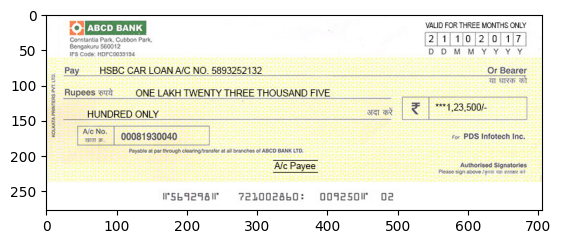

In [48]:
image_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)

In [49]:
img.shape

(278, 706, 3)

In [50]:
image_rgb =cv2.resize(image_rgb,None,fx=2,fy=2,interpolation=cv2.INTER_CUBIC)

In [51]:
image_rgb.shape


(556, 1412, 3)

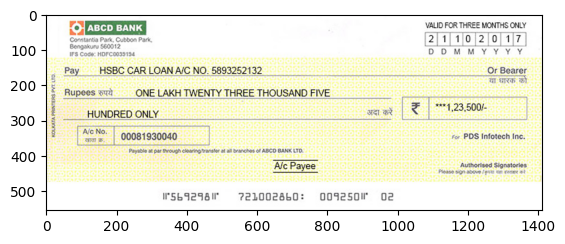

In [52]:
plt.imshow(image_rgb)

In [53]:
image_rgb.shape

(556, 1412, 3)

In [54]:
image_rgb = cv2.cvtColor(image_rgb, cv2.COLOR_BGR2GRAY)

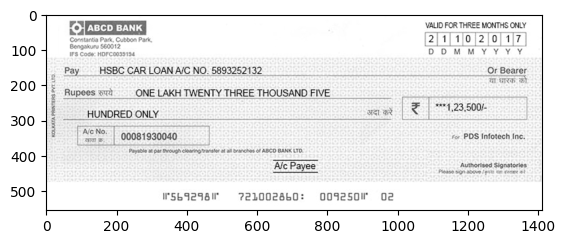

In [55]:

plt.imshow(image_rgb, cmap="gray")

In [56]:
text = pyt.image_to_string(image_rgb,lang="eng")

In [57]:
print(text)

KOLKATA PRINTERS PVT.LTD.

1O] ABCD BANK VALID FOR THREE MONTHS ONLY

Constantia Park, Cubdon Park, 2 [1] 1Jo [2] o] 1] Lg
pea otelhenteee ODOOMMYYYY
Pay HSBC CAR LOAN A/C NO. 5893252132 £ Or Bearer

U1 aR. HY

Rupees wu ONE LAKH TWENTY THREE THOUSAND FIVE

HUNDRED ONLY pntniCto) Bi < 1,23,500/-

Alc No.

ems, | 00081930040 ror PDS Infotech Inc.
Payable at par through cloaring/ranster af ait beanchos of ABCO BANK LTD,
Authorised Signat
fic Payee: Fanssldier toa foe me ecoaeat

Wsb92e98I" 721002860: oo%esolr Oe



In [58]:
# function to remove noise and unnecasry characters from string

def clean_text(text):
    if  text !=' 'or text != ' 'or text != '':
        text = re.sub('[^A-Za-z0-9-/,.()]+', '',text)
        text = text.strip()
        text = re.sub(r'\{2,}','',text)

    return text

In [59]:
text_clean = clean_text(text)

In [60]:
text_clean

'KOLKATAPRINTERSPVT.LTD.1OABCDBANKVALIDFORTHREEMONTHSONLYConstantiaPark,CubdonPark,211Jo2o1LgpeaotelhenteeeODOOMMYYYYPayHSBCCARLOANA/CNO.5893252132OrBearerU1aR.HYRupeeswuONELAKHTWENTYTHREETHOUSANDFIVEHUNDREDONLYpntniCto)Bi1,23,500/-AlcNo.ems,00081930040rorPDSInfotechInc.Payableatparthroughcloaring/ransterafaitbeanchosofABCOBANKLTD,AuthorisedSignatficPayeeFanssldiertoafoemeecoaeatWsb92e98I721002860ooesolrOe'

In [61]:
image_rgb.shape

(556, 1412)

In [62]:
micr_img = image_rgb[450:,:]

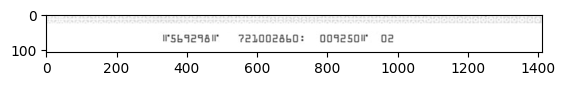

In [63]:
plt.imshow(micr_img,cmap="gray")

In [64]:
text= pyt.image_to_string(micr_img, "eng")

In [65]:
text

'rsb9e9ar\n\n721002860:\n\naosesolr\n\n02\n'

In [66]:
print(text)

rsb9e9ar

721002860:

aosesolr

02



In [67]:
text= pyt.image_to_string(micr_img,lang="mcr")

In [68]:
text

'd569298d\n\n7210828601\n\n009250d\n\n02\n'

In [69]:
print(text)

d569298d

7210828601

009250d

02



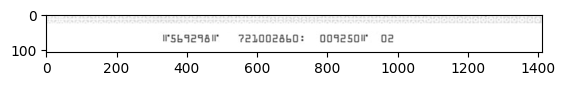

In [70]:
plt.imshow(micr_img,cmap="gray")

In [71]:
text

'd569298d\n\n7210828601\n\n009250d\n\n02\n'

In [74]:
clean_text(text)

'd569298d7210828601009250d02'